In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
import keras
from keras.models import Sequential, Model
from keras.layers import *
from keras.utils import Sequence
from keras.layers import Conv2D, MaxPooling2D
from qkeras import *

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import os
import random
from datetime import datetime
import time

import matplotlib.pyplot as plt

pi = 3.14159265359

maxval=1e9
minval=1e-9



2025-09-13 16:46:52.965687: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# os.chdir('SmartPix/data_generator')
os.chdir('SmartPix/BetterDG')
!pwd

/home/das214/SmartPix/BetterDG


In [2]:
!ls

'2s Shuffled2dHist.png'			       Old_training_stuff
'3x3 Mean Filter with 133e Thresh2dHist.png'   OptimizedDataGeneratorNew.py
 80e_noise2dHist.png			       OptimizedDataGenerator.py
 BetterDG				       OptimizedDataGenerator_v2.py
 contained.ipynb			       Plots
 dataloaders				       plotting
 Dataset_generation			       preselection_processor.py
 dataset_utils.py			       __pycache__
 docs					       requirements.txt
 evaluate.py				       ScratchNB_filter.ipynb
 from_weights-Copy1.ipynb		       Scratch_notebook.ipynb
 from_weights.ipynb			       site
 from_weights-New.ipynb			       test_4x4.csv
 jennets-autoencoder.ipynb		       test_run.py
 loss.py				       trained_models
 Make_datafiles_by_clustsize.ipynb	       trained_models_bad
 mean_filtering.ipynb			       train_model_ben_new2.ipynb
 Merge_plan_lab.ipynb			       train_model_ben_new3.ipynb
 mergeplan.py				       train_model_ben_new.ipynb
'MF3_T133 5x5 kernel size2dHist.png'	       train_model_Better_DG.ipynb
 Misc					  

In [14]:
import importlib
import OptimizedDataGenerator_v2

importlib.reload(OptimizedDataGenerator_v2)
from OptimizedDataGenerator_v2 import OptimizedDataGenerator


In [7]:
#from dataprep import *
# from OptimizedDataGenerator_v2 import OptimizedDataGenerator
from loss import *
from models import *

In [8]:
dataset_base_dir = "/uscms/home/bweiss/nobackup/smart-pixels/"
tfrecords_base_dir = os.path.join(dataset_base_dir, "tfrecords")

dataset_dir_train = os.path.join(dataset_base_dir, "dataset_3sr_16x16_50x12P5_parquets", 'train/')
dataset_dir_val = os.path.join(dataset_base_dir, "dataset_3sr_16x16_50x12P5_parquets", 'test/')

tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train",'threshold_testing')
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val",'threshold_testing')

print(dataset_dir_val)
batch_size = 5000
val_batch_size = 5000
train_file_size = 80
val_file_size = 20

/uscms/home/bweiss/nobackup/smart-pixels/dataset_3sr_16x16_50x12P5_parquets/test/


In [17]:
'''CHANGE THRESHOLDS AND TO_STANDARDIZE!!'''
start_time = time.time()
validation_generator = OptimizedDataGenerator(
    dataset_base_dir = dataset_dir_val,
    file_type = "parquet",
    data_format = "3D",
    batch_size = val_batch_size,
    # optimize_batch_size = True,
    file_count = val_file_size,
    to_standardize= False,
    select_contained = True,
    noise = [0,80], #[mean, sigma]
    min_threshold = 400,
    max_threshold = None,
    labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
    input_shape = (2,16,16), # (20,13,21),
    transpose = (0,2,3,1),
    shuffle = False, 
    files_from_end=True,

    tfrecords_dir = tfrecords_dir_val,
    use_time_stamps = [0,19],
    max_workers = 2
)

print("--- Validation generator %s seconds ---" % (time.time() - start_time))

Processing Files...: 100%|██████████| 20/20 [00:04<00:00,  4.42it/s]


Directory /uscms/home/bweiss/nobackup/smart-pixels/tfrecords/TFR_val/threshold_testing is removed...


Saving batches as TFRecords: 100%|██████████| 21/21 [00:10<00:00,  2.05it/s]


Metadata saved successfully ast /uscms/home/bweiss/nobackup/smart-pixels/tfrecords/TFR_val/threshold_testing/metadata.json
Loading metadata from /uscms/home/bweiss/nobackup/smart-pixels/tfrecords/TFR_val/threshold_testing/metadata.json
--- Validation generator 15.265104532241821 seconds ---


In [7]:
# training generator
start_time = time.time()
training_generator = OptimizedDataGenerator(
    dataset_base_dir = dataset_dir_train,
    file_type = "parquet",
    data_format = "3D",
    batch_size = batch_size,
    # optimize_batch_size = True,
    file_count = train_file_size,
    to_standardize= True,
    select_contained = True,
    labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
    input_shape = (2,16,16), # (20,13,21),
    transpose = (0,2,3,1),
    shuffle = False, # True 
    noise = [0,80],
    threshold = 400,
    tfrecords_dir = tfrecords_dir_train,
    use_time_stamps = [0,19],
    max_workers = 2
)
print("--- Training generator %s seconds ---" % (time.time() - start_time))

Processing Files...: 100%|██████████| 80/80 [00:31<00:00,  2.56it/s]


Directory /uscms/home/bweiss/nobackup/smart-pixels/tfrecords/TFR_train/3sr_16x16_80eN_400eT does not exist and cannot be removed.


Saving batches as TFRecords: 100%|██████████| 84/84 [00:45<00:00,  1.83it/s]


Metadata saved successfully ast /uscms/home/bweiss/nobackup/smart-pixels/tfrecords/TFR_train/3sr_16x16_80eN_400eT/metadata.json
Loading metadata from /uscms/home/bweiss/nobackup/smart-pixels/tfrecords/TFR_train/3sr_16x16_80eN_400eT/metadata.json


--- Training generator 78.59373044967651 seconds ---


In [5]:
# Loading pre-generated TFRecords
validation_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=False,
    seed=42,
    quantize=False,
)

training_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir = tfrecords_dir_train,
    shuffle=False,
    seed=42,
    quantize=False,
)


Loading metadata from /uscms/home/bweiss/nobackup/smart-pixels/tfrecords/TFR_val/3sr_16x16_80eN_400eT/metadata.json


Loading metadata from /uscms/home/bweiss/nobackup/smart-pixels/tfrecords/TFR_train/3sr_16x16_80eN_400eT/metadata.json


tf.Tensor(
[[-0.90068656 -0.55719686 -0.53072673  0.1151311 ]
 [ 0.6422447   0.91322666  0.2867313  -1.046721  ]
 [ 0.86441964  0.6900523  -0.73899055 -0.51502854]
 ...
 [-0.21077555  0.4397422  -0.3037005  -0.83665574]
 [-0.23576191  0.9734979  -0.5340717  -0.0883378 ]
 [-0.17782159  0.18262872  0.5971457  -0.6473533 ]], shape=(5000, 4), dtype=float32)
max: 16.165503
min: 0.0


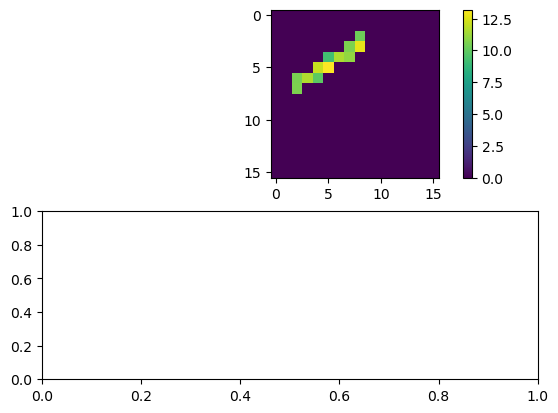

In [18]:
import matplotlib.pyplot as plt
from matplotlib import colors

n=0

cluster = validation_generator[0]
# print(np.max(cluster[0].numpy()))
print(cluster[1])
cluster=cluster[0][:,:,:,1]

print('max:', np.max(cluster.numpy()))
print('min:', np.min(cluster.numpy()))

fig,ax = plt.subplots(2,1)
h = ax[0].imshow(cluster[n])
fig.colorbar(h)

In [11]:
model=CreateModel((16,16,2),n_filters=5,pool_size=3, conv_kernel_size = 3)
model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
    loss=custom_loss
)

model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 16, 16, 2)]       0         
                                                                 
 q_separable_conv2d_1 (QSepa  (None, 14, 14, 5)        33        
 rableConv2D)                                                    
                                                                 
 q_activation_5 (QActivation  (None, 14, 14, 5)        0         
 )                                                               
                                                                 
 q_conv2d_1 (QConv2D)        (None, 14, 14, 5)         30        
                                                                 
 q_activation_6 (QActivation  (None, 14, 14, 5)        0         
 )                                                               
                                                           

In [7]:
from datetime import datetime
tname = '400eThresh_80eNoise'
fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_models/model-{fingerprint}-{tname}-checkpoints'
os.makedirs(base_dir, exist_ok=True)  
checkpoint_filepath = base_dir + '/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.hdf5'

In [8]:
print(fingerprint)

1be2e7e1


In [12]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback

early_stopping_patience = 50

class CustomModelCheckpoint(ModelCheckpoint):
    def on_epoch_end(self, epoch, logs=None):
        super().on_epoch_end(epoch, logs)
        checkpoints = [f for f in os.listdir(base_dir) if f.startswith('weights')]
        if len(checkpoints) > 1:
            checkpoints.sort(key=lambda x: os.path.getmtime(os.path.join(base_dir,x)))
            for checkpoint in checkpoints[:-1]:
                os.remove(os.path.join(base_dir, checkpoint))

es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = CustomModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    save_best_only=True,
    save_freq='epoch',
    verbose=1
)

csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)

In [13]:
history = model.fit(
        x=training_generator,
        validation_data=validation_generator,
        callbacks=[es, mcp, csv_logger],
        epochs=500,
        shuffle=False,
        verbose=1
    )

Epoch 1/500


2025-08-25 20:43:07.806844: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x562e4d859db0


84/84 [==============================] - ETA: 0s - loss: 49244.2422
Epoch 1: val_loss improved from inf to 16330.97168, saving model to ./trained_models/model-1be2e7e1-400eThresh_80eNoise-checkpoints/weights.01-t49244.24-v16330.97.hdf5
84/84 [==============================] - 25s 270ms/step - loss: 49244.2422 - val_loss: 16330.9717
Epoch 2/500
84/84 [==============================] - ETA: 0s - loss: 15146.6406
Epoch 2: val_loss improved from 16330.97168 to 14324.75684, saving model to ./trained_models/model-1be2e7e1-400eThresh_80eNoise-checkpoints/weights.02-t15146.64-v14324.76.hdf5
84/84 [==============================] - 10s 116ms/step - loss: 15146.6406 - val_loss: 14324.7568
Epoch 3/500
84/84 [==============================] - ETA: 0s - loss: 13519.4521
Epoch 3: val_loss improved from 14324.75684 to 12720.04199, saving model to ./trained_models/model-1be2e7e1-400eThresh_80eNoise-checkpoints/weights.03-t13519.45-v12720.04.hdf5
84/84 [==============================] - 10s 116ms/step 

In [ ]:
'''
Epoch 1/1000
305/305 [==============================] - ETA: 0s - loss: 27173.7227
Epoch 1: val_loss improved from inf to 3957.69629, saving model to ./trained_models/model-e0ef8b33-checkpoints/weights.01-t27173.72-v3957.70.hdf5
305/305 [==============================] - 34s 102ms/step - loss: 27173.7227 - val_loss: 3957.6963
Epoch 2/1000
305/305 [==============================] - ETA: 0s - loss: 2077.7952
Epoch 2: val_loss improved from 3957.69629 to -473.36844, saving model to ./trained_models/model-e0ef8b33-checkpoints/weights.02-t2077.80-v-473.37.hdf5
305/305 [==============================] - 30s 97ms/step - loss: 2077.7952 - val_loss: -473.3684
Epoch 3/1000
305/305 [==============================] - ETA: 0s - loss: -935.6221
Epoch 3: val_loss improved from -473.36844 to -1284.97668, saving model to ./trained_models/model-e0ef8b33-checkpoints/weights.03-t-935.62-v-1284.98.hdf5
305/305 [==============================] - 61s 199ms/step - loss: -935.6221 - val_loss: -1284.9767
Epoch 4/1000
305/305 [==============================] - ETA: 0s - loss: -484.1406
Epoch 4: val_loss improved from -1284.97668 to -1554.20630, saving model to ./trained_models/model-e0ef8b33-checkpoints/weights.04-t-484.14-v-1554.21.hdf5
305/305 [==============================] - 36s 116ms/step - loss: -484.1406 - val_loss: -1554.2063
Epoch 5/1000
305/305 [==============================] - ETA: 0s - loss: -3135.4961
Epoch 5: val_loss improved from -1554.20630 to -2936.62402, saving model to ./trained_models/model-e0ef8b33-checkpoints/weights.05-t-3135.50-v-2936.62.hdf5
305/305 [==============================] - 40s 130ms/step - loss: -3135.4961 - val_loss: -2936.6240
Epoch 6/1000
 38/305 [==>...........................] - ETA: 19s - loss: -3885.3333
'''